In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.model_selection import train_test_split
from statsmodels.stats.anova import anova_lm

In [27]:
data = pd.read_csv(r"C:\Users\USER\Documents\R\data\processed\therapy_recovery_clean.csv").drop(columns=['patient_id', 'admit_date', 'discharge_date', 'discharge_date_fix'])

data.head()

,therapy,sex,age_years,age_band,comorbidity,los_final_days
0,std,F,49,40-64 歲,mild,13
1,std,F,60,40-64 歲,none,11
2,new,F,76,65 歲以上,mild,8
3,new,M,53,40-64 歲,mild,12
4,std,F,18,<40 歲,severe,15


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   therapy         200 non-null    object
 1   sex             200 non-null    object
 2   age_years       200 non-null    int64 
 3   age_band        200 non-null    object
 4   comorbidity     200 non-null    object
 5   los_final_days  200 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 9.5+ KB


<BarContainer object of 2 artists>

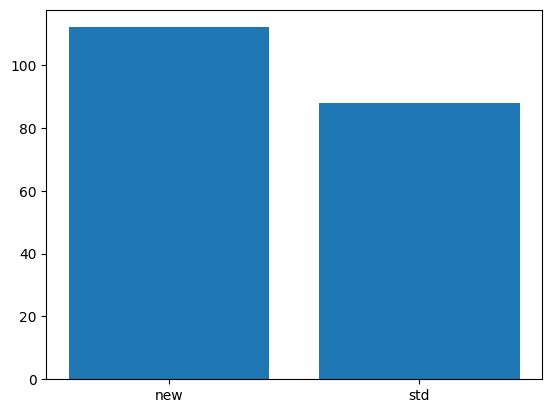

In [39]:
plt.bar(x=data['therapy'].value_counts().index, height=data['therapy'].value_counts().values)


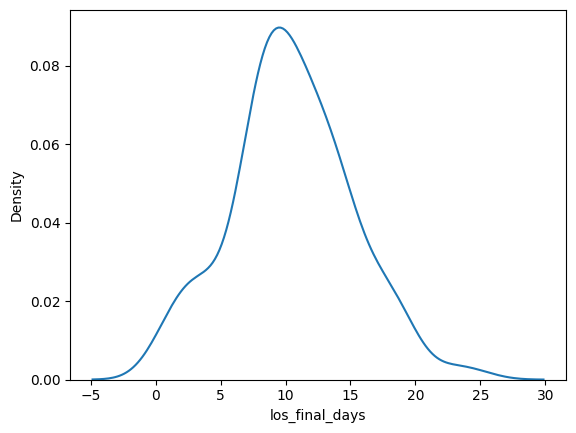

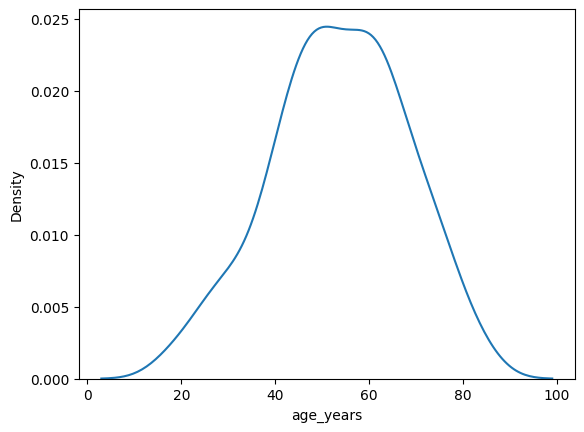

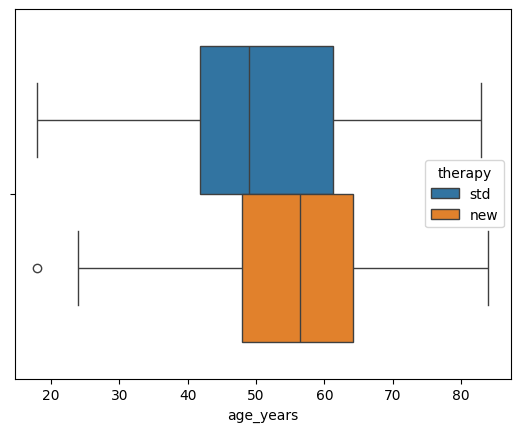

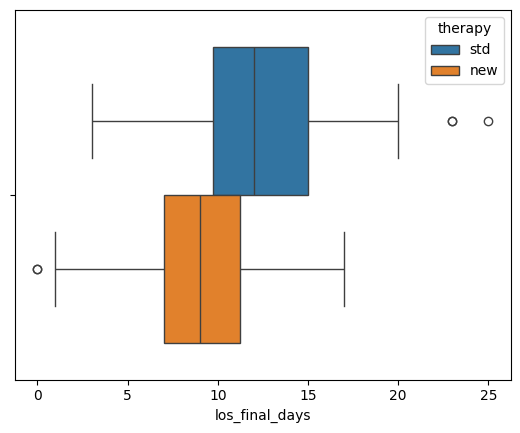

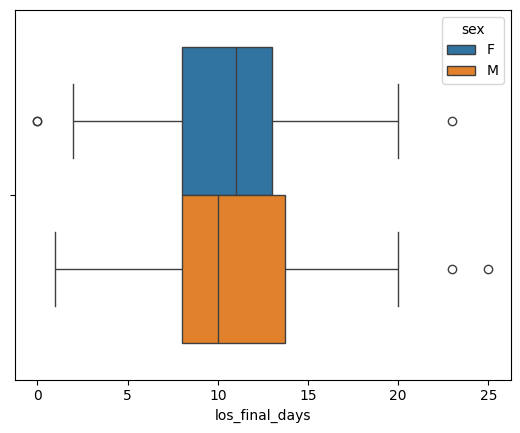

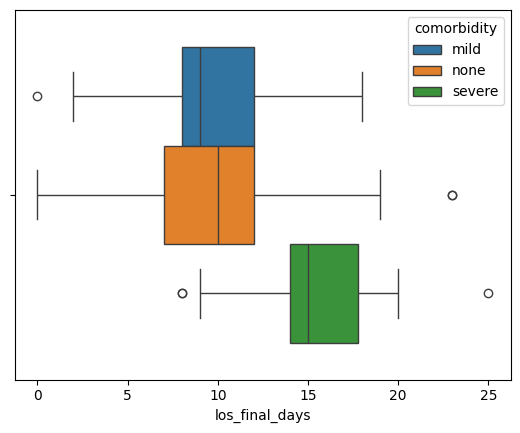

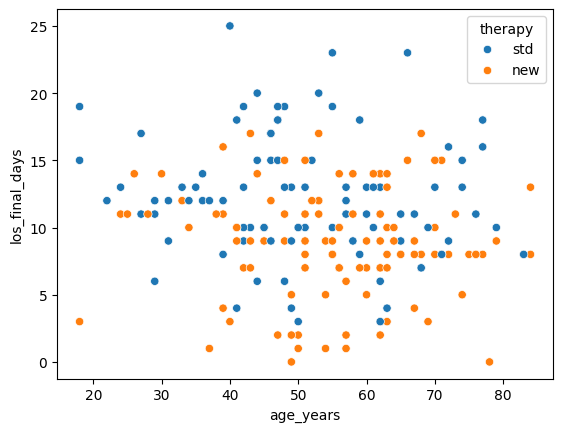

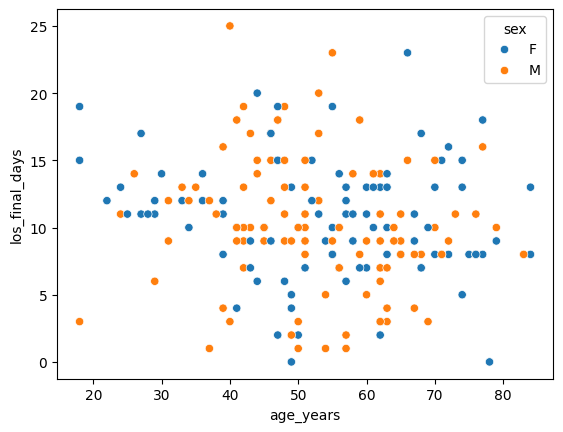

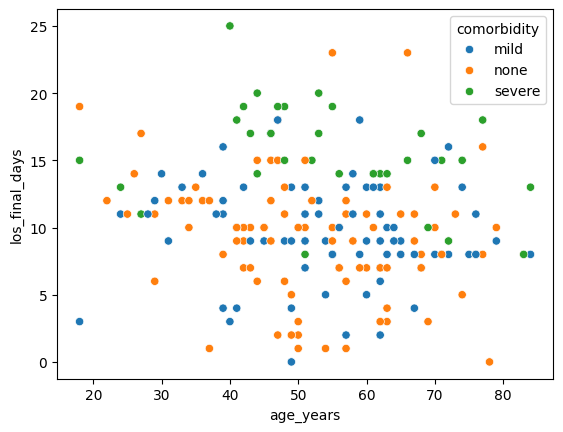

In [68]:
sns.kdeplot(data=data, x='los_final_days')
plt.show()
sns.kdeplot(data=data, x='age_years')
plt.show()
sns.boxplot(data=data, x='age_years', hue='therapy')
plt.show()

sns.boxplot(data=data, x='los_final_days', hue='therapy')
plt.show()

sns.boxplot(data=data, x='los_final_days', hue='sex')
plt.show()

sns.boxplot(data=data, x='los_final_days', hue='comorbidity')
plt.show()

sns.scatterplot(data=data, x='age_years', y='los_final_days', hue='therapy')
plt.show()

sns.scatterplot(data=data, x='age_years', y='los_final_days', hue='sex')
plt.show()

sns.scatterplot(data=data, x='age_years', y='los_final_days', hue='comorbidity')
plt.show()

              n     mean  median     std   IQR    Q1     Q3
comorbidity                                                
mild         77   9.6883     9.0  3.8053  4.00   8.0  12.00
none         89   9.3146    10.0  4.6137  5.00   7.0  12.00
severe       34  15.2353    15.0  3.6520  3.75  14.0  17.75


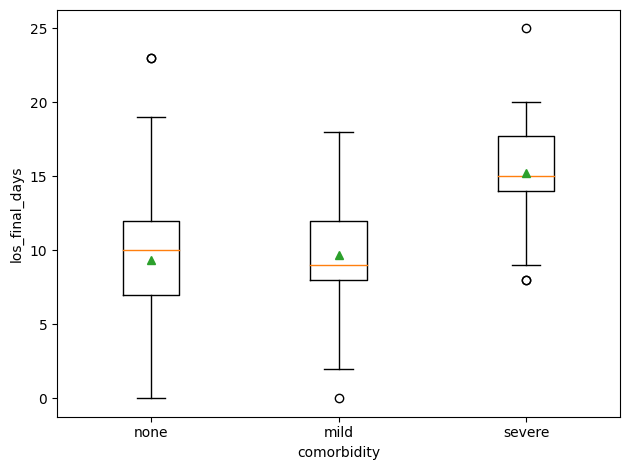

In [85]:
desc = (data.groupby('comorbidity')['los_final_days'].agg(n='count',
                                                          mean='mean', 
                                                          median='median', 
                                                          std='std',
                                                          IQR=lambda x:np.percentile(x, 75)-np.percentile(x, 25), Q1=lambda x:np.percentile(x, 25), Q3=lambda x:np.percentile(x, 75)).round(4))
print(desc)

plt.figure()
order = ['none','mild','severe'] if set(['none','mild','severe']).issubset(set(data['comorbidity'].unique())) else sorted(data['comorbidity'].unique())
groups = [data.loc[data['comorbidity']==g, 'los_final_days'].values for g in order]
plt.boxplot(groups, labels=order, showmeans=True)
plt.xlabel("comorbidity")
plt.ylabel("los_final_days")
plt.tight_layout()
plt.show()

In [88]:
# 等變異檢定（以中位數為中心的 Levene）
lev_stat, lev_p = stats.levene(*groups, center='median')
print(f"\nLevene test (equal variances): stat={lev_stat:.3f}, p={lev_p:.4f}")

# 單因子 ANOVA（參數式）
model = smf.ols("los_final_days ~ C(comorbidity)", data=data).fit()
anova_tbl = anova_lm(model, typ=2)
print("\n=== One-way ANOVA ===")
print(anova_tbl)

SS_between = anova_tbl.loc['C(comorbidity)', 'sum_sq']
SS_resid   = anova_tbl.loc['Residual', 'sum_sq']
eta_sq = SS_between / (SS_between + SS_resid)
print(f"eta^2 = {eta_sq:.3f}")


Levene test (equal variances): stat=1.192, p=0.3056

=== One-way ANOVA ===
                     sum_sq     df          F        PR(>F)
C(comorbidity)   937.926861    2.0  27.062228  4.129104e-11
Residual        3413.828139  197.0        NaN           NaN
eta^2 = 0.216


In [99]:
formula = "los_final_days ~ C(therapy, Treatment('std'))+C(comorbidity, Treatment('none'))"
ols = smf.ols(formula=formula, data=data).fit(cov_type='nonrobust')
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:         los_final_days   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     32.72
Date:                Mon, 06 Oct 2025   Prob (F-statistic):           3.42e-17
Time:                        23:00:17   Log-Likelihood:                -551.18
No. Observations:                 200   AIC:                             1110.
Df Residuals:                     196   BIC:                             1124.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------